# Workshop 03 - Multi-Agent Primary School Tutor

This notebook demonstrates an orchestrated LangGraph workflow with three specialized agents and strict tool permissions.

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == 'notebooks':
    project_root = Path.cwd().parent.resolve()
else:
    project_root = Path.cwd().resolve()

src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

assert os.getenv('OPENAI_API_KEY'), 'Please set OPENAI_API_KEY in your environment first.'

from tutor_multi_agent import build_graph, run_turn

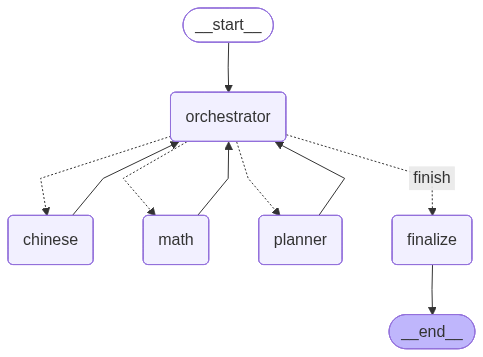

In [2]:
graph = build_graph(model_name='gpt-4o-mini')
graph

In [3]:
import json

def run_case(user_input: str, session_id: str):
    result = run_turn(user_input=user_input, session_id=session_id, model_name='gpt-4o-mini')
    print(f'Input: {user_input}')
    print('Final answer:')
    print(result['final_answer'])
    print('Tool events:')
    print(json.dumps(result['tool_events'], ensure_ascii=False, indent=2))
    print('-' * 60)
    return result

In [4]:
sample_1 = run_case('Give me one classical Chinese poem line and explain it like a primary school teacher.', 'case-chinese')
sample_2 = run_case('For a Grade 3 student, how do we solve 45 - 18 step by step?', 'case-math')
sample_3 = run_case('Based on today\'s date, create a weekly study plan.', 'case-plan')
sample_4 = run_case('First share one poem line, then tell me what is the lenght of the poem plus 3.', 'case-mixed')

Input: Give me one classical Chinese poem line and explain it like a primary school teacher.
Final answer:
Here’s a beautiful line from a classical Chinese poem:

"天涯芳草迷归路，病叶还禁一夜霜。" 

This means: "The fragrant grass at the ends of the earth makes it hard to find the way home, and the sick leaves are still frozen by the night frost."

Let’s break it down:

1. **Fragrant grass**: This represents beauty and nature. It can be very nice to see and smell flowers and grass.
2. **Hard to find the way home**: Sometimes, when we are surrounded by beautiful things, we can get lost or forget where we are going. It reminds us to stay focused on our goals.
3. **Sick leaves and night frost**: This shows that even beautiful things can face challenges, like cold weather. It teaches us that everyone has tough times, but we can still be strong.

So, this poem line tells us to appreciate beauty but also to remember our path and be strong during difficult times. Isn’t that a nice lesson?
Tool events:
[
  "

In [6]:
proof = run_case('Please provide one chinese poem line and explain its meaning.', 'permission-proof')
assert not any('get_date_tool' in event for event in proof['tool_events']), 'Chinese agent must not use get_date_tool.'
print('Permission check passed: no get_date_tool usage in Chinese scenario.')

Input: Please provide one chinese poem line and explain its meaning.
Final answer:
Here’s a line from a Chinese poem:

"自是荷花开较晚，孤负东风。"  
(Zì shì héhuā kāi jiào wǎn, gūfù dōngfēng.)

**Translation:** "The lotus flowers bloom later, missing the chance with the east wind."

**Explanation:**
In this line, the poet talks about lotus flowers that bloom later than other flowers. The "east wind" symbolizes the arrival of spring and good opportunities. By blooming late, the lotus flowers miss the chance to enjoy the warmth and beauty of the early spring. This can mean that sometimes, good things take time, but it can also suggest a feeling of regret for not being able to take advantage of the right moment. 

If you have any questions or want to learn more, just let me know!
Tool events:
[
  "orchestrator llm routes: {\"routes\": [\"chinese\"], \"reason\": \"User requested a Chinese poem line and its explanation.\"}",
  "orchestrator intent queue: ['chinese']",
  "orchestrator -> chinese",
  "ch